# **Perbedaan Hingga**

Pendekatan umum untuk menurunkan perbedaan hingga seharusnya sudah cukup familiar, setidaknya untuk perbedaan orde pertama. Pertimbangkan tiga cara berbeda untuk mendefinisikan turunan pada suatu titik $x_i$

Turunan pertama fungsi $u(x)$ di titik $x_i$:

$$u'(x_i)=\lim _{\Delta x\rightarrow 0}\frac{u(x_i+\Delta x)-u(x_i)}{\Delta x}$$
Karena dalam numerik kita tidak bisa ambil limit, maka kita gunakan pendekatan dengan jarak diskrit $\Delta x$.


Untuk menurunkan bentuk perbedaan hingga, digunakan ekspansi Taylor di sekitar titik $x_i$:
- Ekspansi maju:

$u(x_i+\Delta x)=u(x_i)+\Delta xu'(x_i)+\frac{(\Delta x)^2}{2}u''(x_i)+\frac{(\Delta x)^3}{6}u^{(3)}(x_i)+\cdots$ 

- Ekspansi mundur:

$u(x_i-\Delta x)=u(x_i)-\Delta xu'(x_i)+\frac{(\Delta x)^2}{2}u''(x_i)-\frac{(\Delta x)^3}{6}u^{(3)}(x_i)+\cdots$

**Penurunan Rumus Perbedaan Hingga**

a) Forward Difference $(D_+)$

$D_+u(x_i)=\frac{u(x_i+\Delta x)-u(x_i)}{\Delta x}$

Substitusi ekspansi Taylor:

$$D_+u(x_i)=\frac{\Delta xu'(x_i)+\frac{(\Delta x)^2}{2}u''(x_i)+O((\Delta x)^3)}{\Delta x}$$

$$D_+u(x_i)=u'(x_i)+\frac{\Delta x}{2}u''(x_i)+O(\Delta x^2)$$

b) Backward Difference $(D_-)$

$D_-u(x_i)=\frac{u(x_i)-u(x_i-\Delta x)}{\Delta x}$

Substitusi ekspansi Taylor:

$$D_-u(x_i)=\frac{\Delta xu'(x_i)-\frac{(\Delta x)^2}{2}u''(x_i)+O((\Delta x)^3)}{\Delta x}$$
$$D_-u(x_i)=u'(x_i)-\frac{\Delta x}{2}u''(x_i)+O(\Delta x^2)$$


c) Central Difference $(D_0)$

$D_0u(x_i)=\frac{u(x_i+\Delta x)-u(x_i-\Delta x)}{2\Delta x}$

Substitusi ekspansi Taylor:

$$D_0u(x_i)=\frac{2\Delta xu'(x_i)+O((\Delta x)^3)}{2\Delta x}$$
$$D_0u(x_i)=u'(x_i)+O(\Delta x^2)$$

Sehingga,
$$
    u'(x_i) = \lim_{\Delta x \rightarrow 0} \left \{ \begin{aligned} 
        &\frac{u(x_i + \Delta x) - u(x_i)}{\Delta x} & \equiv D_+ u(x_i)\\
        &\frac{u(x_i + \Delta x) - u(x_i - \Delta_x)}{2 \Delta x} & \equiv D_0 u(x_i)\\
        &\frac{u(x_i) - u(x_i - \Delta_x)}{\Delta x} & \equiv D_- u(x_i).
    \end{aligned} \right .
$$

![Approximations to $u'(x)$](./images/fd_basic.png)

Gambar tersebut memperlihatkan bagaimana turunan fungsi dapat diperkirakan dari data diskret menggunakan tiga metode finite difference, dan menunjukkan bahwa central difference biasanya paling mendekati turunan sebenarnya.

## **Polinomial Interpolasi**

alah satu cara untuk menurunkan pendekatan perbedaan hingga adalah dengan mencari polinomial interpolasi melalui stencil yang diberikan, lalu langsung mendiferensiasikannya. Diberikan N+1 titik $(x_0,u(x_0)),(x_1,u(x_1)),\ldots ,(x_N,u(x_N))$ dengan asumsi bahwa semua $x_i$ unik, maka polinomial interpolasi $P_N(x)$ dapat dituliskan sebagai

$$
    P_N(x) = \sum^{N}_{i=0} u(x_i) \ell_i(x)
$$

dimana
- $P_N(x)$ = polinomial interpolasi  
- $l_i(x)$ = basis polinomial Lagrange

Basis $l_i(x)$ harus memenuhi:

$$l_i(x_j) = 
\begin{cases} 
1 & \text{jika } i = j \\[6pt]
0 & \text{jika } i \ne j 
\end{cases}$$

Sehingga
$$P_N(x_i) = u(x_i)$$

Menurunkan Bentuk $P_N(x_i) = u(x_i)$ agar bernilai nol di semua $( x_j )$ dengan $j \ne i$ kita buat faktor:  
$$(x - x_j)$$
untuk semua $j \ne i$

Sehingga pembilangnya:  
$$(x - x_0)(x - x_1)\ldots(x - x_{i-1})(x - x_{i+1})\ldots(x - x_N)$$

Jika kita substitusi $x = x_i$:

$$(x_i - x_0)(x_i - x_1)\ldots(x_i - x_{i-1})(x_i - x_{i+1})\ldots(x_i - x_N)$$

Agar hasilnya 1, kita bagi dengan nilai tersebut.

Maka:

$$l_i(x) = \frac{(x - x_0)(x - x_1)\ldots(x - x_{i-1})(x - x_{i+1})\ldots(x - x_N)}{(x_i - x_0)(x_i - x_1)\ldots(x_i - x_{i-1})(x_i - x_{i+1})\ldots(x_i - x_N)}$$

Sehingga
$$
    \ell_i(x) = \prod^{N}_{j=0, j \neq i} \frac{x - x_j}{x_i - x_j} = \frac{x - x_0}{x_i - x_0} \frac{x - x_1}{x_i - x_1} \cdots \frac{x - x_{i-1}}{x_i - x_{i-1}}\frac{x - x_{i+1}}{x_i - x_{i+1}} \cdots \frac{x - x_{N}}{x_i - x_{N}}
$$


Perhatikan bahwa $\ell _i(x_i)=1$ dan untuk semua $j\neq i$, berlaku $\ell _i(x_j)=0$.
Karena kita mengetahui cara mendiferensiasi polinomial, maka kita dapat langsung menghitung pendekatan perbedaan hingga yang diberikan berdasarkan titik-titik data tersebut.

**Contoh: Stencil 2 Titik**
Misalkan kita memiliki dua titik untuk membentuk pendekatan terhadap turunan. Polinomial interpolasi melalui dua titik adalah sebuah fungsi linear dengan bentuk
$P_1(x)=u(x_0)\frac{x-x_1}{x_0-x_1}+u(x_1)\frac{x-x_0}{x_1-x_0}$.
Turunkan pendekatan yang berpusat di $x_0$ dari polinomial ini.

Mendiferensiasikan $P_1(x)$ menghasilkan

$$
    P'_1(x) = u(x_0) \frac{1}{x_0 - x_1} + u(x_1) \frac{1}{x_1 - x_0}.
$$

Jika kita biarkan jarak antara $x_0$ dan $x_1$ sebagai $\Delta x=x_1-x_0$, maka kita dapat menuliskannya sebagai

$$
    P'_1(x) = \frac{u(x_1) - u(x_0)}{\Delta x}
$$

yang merupakan bentuk umum dari $D_-u(x)$ dan $D_+u(x)$ di atas.

Jika kita perpanjang menjadi tiga titik, maka polinomial interpolasi yang diperoleh adalah
$$
    P_2(x) = u(x_0) \frac{x - x_1}{x_0 - x_1} \frac{x - x_2}{x_0 - x_2} + u(x_1) \frac{x - x_0}{x_1 - x_0} \frac{x - x_2}{x_1 - x_2} + u(x_2) \frac{x - x_0}{x_2 - x_0} \frac{x - x_1}{x_2 - x_1}.
$$

Mendiferensiasikan polinomial ini menghasilkan
$$\begin{aligned}
    P'_2(x) &= u(x_0) \left( \frac{1}{x_0 - x_1} \frac{x - x_2}{x_0 - x_2} + \frac{x - x_1}{x_0 - x_1} \frac{1}{x_0 - x_2}\right )+ u(x_1) \left ( \frac{1}{x_1 - x_0} \frac{x - x_2}{x_1 - x_2} + \frac{x - x_0}{x_1 - x_0} \frac{1}{x_1 - x_2} \right )+ u(x_2)\left ( \frac{1}{x_2 - x_0} \frac{x - x_1}{x_2 - x_1} + \frac{x - x_0}{x_2 - x_0} \frac{1}{x_2 - x_1} \right ) \\
    &= u(x_0) \left(\frac{x - x_2}{2 \Delta x^2} + \frac{x - x_1}{2 \Delta x^2} \right )+ u(x_1) \left ( \frac{x - x_2}{-\Delta x^2} + \frac{x - x_0}{-\Delta x^2} \right )+ u(x_2)\left ( \frac{x - x_1}{2\Delta x^2} + \frac{x - x_0}{2 \Delta x^2} \right ) \\
    &=\frac{u(x_0)}{2\Delta x^2} (2x - x_2 - x_1)+ \frac{u(x_1)}{-\Delta x^2} ( 2x - x_2 - x_0)+ \frac{u(x_2)}{2\Delta x^2}( 2x - x_1 - x_0) \\
    &=\frac{u(x_0)}{2\Delta x^2} (2x - x_2 - x_1)+ \frac{u(x_1)}{-\Delta x^2} ( 2x - x_2 - x_0)+ \frac{u(x_2)}{2\Delta x^2}( 2x - x_1 - x_0).
\end{aligned}$$

Jika sekarang kita evaluasi turunan pada $x_1$, dengan asumsi bahwa ini adalah titik pusat, maka diperoleh
$$\begin{aligned}
    P'_2(x_1) &= \frac{u(x_0)}{2\Delta x^2} (x_1 - x_2)+ \frac{u(x_1)}{-\Delta x^2} ( x_1 - x_2 + x_1 - x_0)+ \frac{u(x_2)}{\Delta x^2}( x_1 - x_0) \\
    &= \frac{u(x_0)}{2\Delta x^2} (-\Delta x)+ \frac{u(x_1)}{-\Delta x^2} ( -\Delta x + \Delta x)+ \frac{u(x_2)}{\Delta x^2}( 2\Delta x) \\
    &= \frac{u(x_2) - u(x_0)}{2 \Delta x}
\end{aligned}$$
Hasil ini memberikan kita pendekatan ketiga yang telah disebutkan sebelumnya.


Metode Deret Taylor
Cara lain untuk menurunkan pendekatan perbedaan hingga dapat dihitung dengan menggunakan deret Taylor dan metode koefisien tak tentu.
$$u(x) = u(x_n) + (x - x_n) u'(x_n) + \frac{(x - x_n)^2}{2!} u''(x_n) + \frac{(x - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x - x_n)^4)$$

Misalkan kita ingin menurunkan pendekatan turunan pertama dengan akurasi orde kedua seperti yang baru saja dilakukan, hal ini membutuhkan nilai $(x_{n+1},u(x_{n+1}))$ dan $(x_{n-1},u(x_{n-1}))$. Kita dapat mengekspresikan nilai-nilai tersebut melalui pendekatan deret Taylor di atas sebagai

$$\begin{aligned}
    u(x_{n+1}) &= u(x_n) + (x_{n+1} - x_n) u'(x_n) + \frac{(x_{n+1} - x_n)^2}{2!} u''(x_n) + \frac{(x_{n+1} - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x_{n+1} - x_n)^4) \\
    &= u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) + \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) 
\end{aligned}$$

Dan

$$\begin{aligned}
    u(x_{n-1}) &= u(x_n) + (x_{n-1} - x_n) u'(x_n) + \frac{(x_{n-1} - x_n)^2}{2!} u''(x_n) + \frac{(x_{n-1} - x_n)^3}{3!} u'''(x_n) + \mathcal{O}((x_{n-1} - x_n)^4) \\
&= u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) - \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) 
\end{aligned}$$

Sekarang, untuk mengetahui bagaimana menggabungkan ekspansi tersebut menjadi sebuah ekspresi turunan, kita mengasumsikan bahwa pendekatan kita berbentuk
$$u'(x_n) + R(x_n) = A u(x_{n+1}) + B u(x_n) + C u(x_{n-1})$$
di mana $R(x_n)$ adalah galat (error) dari pendekatan kita.

Dengan memasukkan pendekatan deret Taylor, kita peroleh

$$u'(x_n) + R(x_n) = A \left ( u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) + \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4)\right ) + B u(x_n) + C \left ( u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) - \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) \right )$$

Karena kita menginginkan $R(x_n)=\mathcal{O}(\Delta x^2)$, maka semua suku dengan orde lebih rendah dari ini harus hilang, kecuali suku-suku yang mengalikan $u'(x_n)$, karena suku tersebut harus berjumlah 1 untuk memberikan pendekatan turunan yang benar. Dengan mengumpulkan suku-suku yang memiliki turunan sama $u^{(k)}(x_n)$, kita memperoleh serangkaian ekspresi untuk koefisien A, B, dan C berdasarkan fakta bahwa kita ingin sebuah pendekatan untuk $u'(x_n)$.
Suku dengan n=0 yang terkumpul adalah A+B+C, dan diset sama dengan 0 karena kita ingin suku $u(x_n)$ hilang:

$$\begin{aligned}
    u(x_n): & \quad A + B + C = 0 \\
    u'(x_n): & \quad A \Delta x - C \Delta x = 1  \\
    u''(x_n): & \quad A \frac{\Delta x^2}{2} + C \frac{\Delta x^2}{2} = 0 
\end{aligned}$$



Persamaan terakhir ini \Rightarrow A=-C. Dengan menggunakan hasil ini pada persamaan kedua diperoleh $A = \frac{1}{2 \Delta x}$ dan $C = -\frac{1}{2 \Delta x}$ . Persamaan pertama kemudian menghasilkan B=0. Jika semuanya digabungkan, kita mendapatkan ekspresi sebelumnya beserta estimasi galatnya:

$$u'(x_n) + R(x_n) = \frac{u(x_{n+1}) - u(x_{n-1})}{2 \Delta x} + \frac{1}{2 \Delta x} \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) + \frac{1}{2 \Delta x} \frac{\Delta x^3}{3!} u'''(x_n) + \mathcal{O}(\Delta x^4) $$

$$R(x_n) = \frac{\Delta x^2}{3!} u'''(x_n) + \mathcal{O}(\Delta x^3) = \mathcal{O}(\Delta x^2)$$

**Contoh: Turunan Orde Pertama**

0.6613879270715355 = 0.6613879270715354


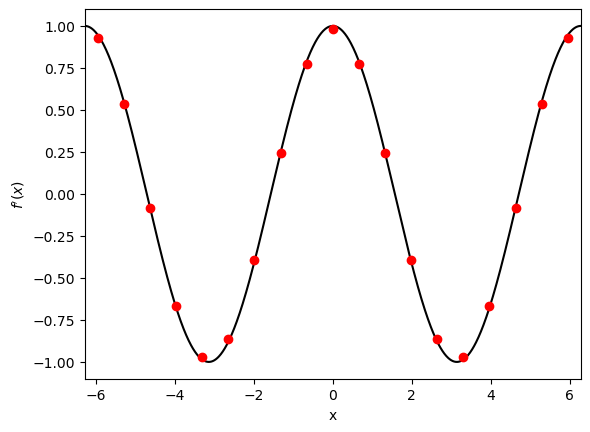

In [ ]:
import numpy                     # Mengimpor library numpy untuk perhitungan numerik
import matplotlib.pyplot as plt  # Mengimpor matplotlib untuk membuat grafik

# Mendefinisikan fungsi f(x) = sin(x)
f = lambda x: numpy.sin(x)

# Mendefinisikan turunan analitik dari fungsi tersebut yaitu f'(x) = cos(x)
f_prime = lambda x: numpy.cos(x)

# Menggunakan diskretisasi seragam (uniform discretization)
x = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, 1000)  
# Membuat 1000 titik dari -2π sampai 2π untuk grafik kontinu

N = 20  
# Jumlah titik grid yang digunakan untuk pendekatan numerik

x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)  
# Membuat 20 titik grid diskrit pada domain yang sama

delta_x = x_hat[1] - x_hat[0]  
# Menghitung jarak antar titik grid (Δx)

print("%s = %s" % (delta_x, (x_hat[-1] - x_hat[0]) / (N - 1)))  
# Mengecek bahwa Δx sesuai dengan rumus panjang domain / jumlah interval

# Menghitung turunan menggunakan metode Forward Difference dengan loop
f_prime_hat = numpy.empty(x_hat.shape)  
# Membuat array kosong untuk menyimpan hasil turunan numerik

for i in range(N - 1):  
    # Loop dari titik pertama sampai titik sebelum terakhir
    f_prime_hat[i] = (f(x_hat[i+1]) - f(x_hat[i])) / delta_x
    # Rumus Forward Difference:
    # f'(x) ≈ (f(x_i+1) - f(x_i)) / Δx

# Perhitungan di titik terakhir menggunakan pendekatan backward difference
f_prime_hat[-1] = (f(x_hat[i]) - f(x_hat[i-1])) / delta_x

# Alternatif perhitungan menggunakan operasi vektor (tidak dipakai di sini)
# f_prime_hat[:-1] = (f(x_hat[1:]) - f(x_hat[:-1])) / (delta_x)

# Menggunakan Backward Difference khusus untuk titik terakhir domain
f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x  
# Karena di ujung domain tidak ada titik di depannya

# Membuat figure grafik
fig = plt.figure()

# Menambahkan subplot
axes = fig.add_subplot(1, 1, 1)

# Plot turunan analitik (cos(x))
axes.plot(x, f_prime(x), 'k')
# 'k' berarti garis hitam

# Plot hasil turunan numerik (Forward Difference)
axes.plot(x_hat + 0.5 * delta_x, f_prime_hat, 'ro')
# 'ro' berarti titik merah
# +0.5Δx karena forward difference merepresentasikan nilai di tengah interval

# Mengatur batas sumbu x
axes.set_xlim((x[0], x[-1]))

# Mengatur batas sumbu y
axes.set_ylim((-1.1, 1.1))

# Memberi label sumbu x
axes.set_xlabel("x")

# Memberi label sumbu y
axes.set_ylabel(r"$f'(x)$")

# Menampilkan grafik
plt.show()

Dengan menggunakan pendekatan deret Taylor, mari kita turunkan rumus turunan kedua dengan akurasi orde dua. Kita akan menggunakan titik-titik yang sama dan deret Taylor yang dipusatkan di $x=x_n$, sehingga kita memperoleh ekspresi yang sama seperti sebelumnya:

$$\begin{aligned}
    u''(x_n) + R(x_n) &= \quad A \left ( u(x_n) + \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) + \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) + \mathcal{O}(\Delta x^5)\right ) \\
    &\quad+ B u(x_n) \\
    &\quad+ C \left ( u(x_n) - \Delta x u'(x_n) + \frac{\Delta x^2}{2!} u''(x_n) - \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n) + \mathcal{O}(\Delta x^5) \right )
\end{aligned}$$

Namun kali ini kita ingin membiarkan u''(x_n) tetap berada di ruas kanan. Dengan melakukan trik yang sama seperti sebelumnya, kita memperoleh ekspresi berikut:

$$\begin{aligned}
    u(x_n): & \quad A + B + C = 0 \\
    u'(x_n): & \quad A \Delta x - C \Delta x = 0 \\
    u''(x_n): & \quad A \frac{\Delta x^2}{2} + C \frac{\Delta x^2}{2} = 1
\end{aligned}$$

Persamaan kedua menyiratkan bahwa $A=C$, yang jika digabungkan dengan persamaan ketiga menghasilkan

$$A = C = \frac{1}{\Delta x^2}$$

Akhirnya, persamaan pertama memberikan

$$B = -\frac{2}{\Delta x^2}$$

Sehingga ekspresi akhirnya menjadi

$$\begin{aligned}
    u''(x_n) + R(x_n) &= \frac{u(x_{n+1}) - 2 u(x_n) + u(x_{n-1})}{\Delta x^2} \\
&\quad+ \frac{1}{\Delta x^2} \left(\frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n)  - \frac{\Delta x^3}{3!} u'''(x_n) + \frac{\Delta x^4}{4!} u^{(4)}(x_n)  \right) + \mathcal{O}(\Delta x^5)
\end{aligned}$$

dengan 

$$R(x_n) = \frac{\Delta x^2}{12} u^{(4)}(x_n) + \mathcal{O}(\Delta x^3)$$

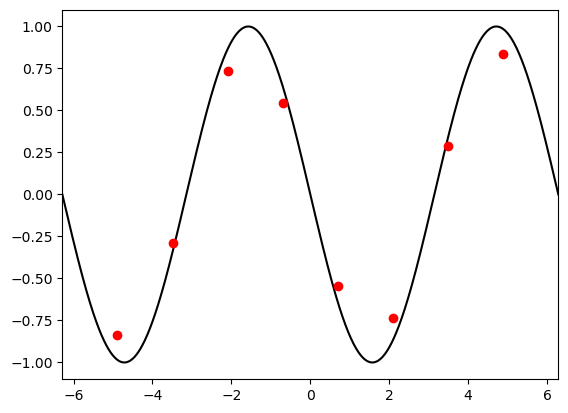

In [ ]:
import numpy                      # Library untuk perhitungan numerik
import matplotlib.pyplot as plt   # Library untuk membuat grafik

# Mendefinisikan fungsi f(x) = sin(x)
f = lambda x: numpy.sin(x)

# Mendefinisikan turunan kedua analitik dari fungsi tersebut
# Turunan kedua sin(x) adalah -sin(x)
f_dubl_prime = lambda x: -numpy.sin(x)

# Menggunakan diskretisasi seragam (uniform discretization)
x = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, 1000)
# Membuat 1000 titik kontinu dari -2π sampai 2π untuk grafik halus

N = 10
# Jumlah titik grid diskrit untuk pendekatan numerik

x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)
# Membuat 10 titik diskrit dalam domain yang sama

delta_x = x_hat[1] - x_hat[0]
# Menghitung jarak antar titik grid (Δx)

# Menghitung turunan kedua secara numerik
f_dubl_prime_hat = numpy.empty(x_hat.shape)
# Membuat array kosong untuk menyimpan hasil turunan kedua numerik

# Menggunakan metode Central Difference untuk titik tengah
f_dubl_prime_hat[1:-1] = (f(x_hat[2:]) - 2.0 * f(x_hat[1:-1]) + f(x_hat[:-2])) / (delta_x**2)

# Rumus Central Difference turunan kedua:
# f''(x_i) ≈ (f(x_i+1) - 2f(x_i) + f(x_i-1)) / (Δx²)
# Digunakan untuk semua titik kecuali titik pertama dan terakhir

# Menggunakan rumus khusus untuk titik pertama (edge domain)
f_dubl_prime_hat[0] = (2.0 * f(x_hat[0]) - 5.0 * f(x_hat[1]) + 4.0 * f(x_hat[2]) - f(x_hat[3])) / delta_x**2
# Ini adalah pendekatan turunan kedua di batas kiri domain

# Menggunakan rumus khusus untuk titik terakhir
f_dubl_prime_hat[-1] = (2.0 * f(x_hat[-1]) - 5.0 * f(x_hat[-2]) + 4.0 * f(x_hat[-3]) - f(x_hat[-4])) / delta_x**2
# Pendekatan turunan kedua di batas kanan domain

# Membuat figure grafik
fig = plt.figure()

# Menambahkan subplot
axes = fig.add_subplot(1, 1, 1)

# Plot turunan kedua analitik
axes.plot(x, f_dubl_prime(x), 'k')
# Garis hitam menunjukkan solusi sebenarnya

# Plot hasil turunan kedua numerik
axes.plot(x_hat, f_dubl_prime_hat, 'ro')
# Titik merah menunjukkan hasil metode finite difference

# Mengatur batas sumbu x
axes.set_xlim((x[0], x[-1]))

# Mengatur batas sumbu y
axes.set_ylim((-1.1, 1.1))

# Menampilkan grafik
plt.show()

Untuk pendekatan perbedaan hingga secara umum yang terletak di $\bar {x}$ terhadap turunan ke-k dengan stencil arbitrer $N\geq k+1$ titik $x_1$, $\ldots ,x_N$, kita dapat menggunakan beberapa generalisasi dari metode di atas. Perlu dicatat bahwa meskipun biasanya $\bar {x}$ adalah salah satu titik stencil, hal ini tidaklah wajib. Kita juga mengasumsikan bahwa $u(x)$ cukup mulus sehingga deret Taylor kita tetap valid.


Pada setiap titik stencil kita memiliki pendekatan
$$
    u(x_i) = u(\bar{x}) + (x_i - \bar{x})u'(\bar{x}) + \cdots + \frac{1}{k!}(x_i - \bar{x})^k u^{(k)}(\bar{x}) + \cdots.
$$

Mengikuti metodologi kita di atas, kita ingin menemukan kombinasi linear dari ekspansi deret Taylor tersebut sehingga
$$
    u^{(k)}(\bar{x}) + \mathcal{O}(\Delta x^p) = a_1 u(x_1) + a_2 u(x_2) + a_3 u(x_3) + \cdots + a_n u(x_n).
$$
Perlu dicatat bahwa $\Delta x$ secara umum dapat bervariasi, dan perilaku asimtotik dari metode ini akan ditentukan oleh semacam jarak rata-rata atau kadang jarak maksimum antar titik stencil.


Menggeneralisasi pendekatan di atas dengan metode koefisien tak tentu, kita ingin menghilangkan bagian dari pendekatan tersebut yang berada di depan turunan dengan orde lebih kecil dari k. Kondisi untuk hal ini adalah

$$
    \frac{1}{(i - 1)!} \sum^N_{j=1} a_j (x_j - \bar{x})^{(i-1)} = \left \{ \begin{aligned}
        1 & & \text{if} \quad i - 1 = k, \\
        0 & & \text{otherwise}
    \end{aligned} \right .
$$

untuk $i=1$,$\ldots ,N$. Dengan asumsi bahwa $x_j$ berbeda satu sama lain, kita dapat menuliskan sistem persamaan ini dalam bentuk sistem Vandermonde yang akan memiliki solusi unik.


In [ ]:
import numpy                     # Library untuk operasi numerik
import scipy.special            # Library scipy untuk fungsi matematika khusus (misalnya faktorial)

def finite_difference(k, x_bar, x):
    """Menghitung koefisien stencil finite difference untuk turunan ke-k"""
    
    N = x.shape[0]              
    # Menentukan jumlah titik grid yang digunakan
    
    A = numpy.ones((N, N))      
    # Membuat matriks A berukuran N x N yang awalnya berisi 1
    
    x_row = x - x_bar           
    # Menghitung jarak setiap titik terhadap titik pusat (x_bar)
    
    for i in range(1, N):
        A[i, :] = x_row ** i / scipy.special.factorial(i)
        # Mengisi baris matriks A dengan ekspansi Taylor:
        # (x - x_bar)^i / i!
        # digunakan untuk membentuk sistem persamaan Taylor series
    
    b = numpy.zeros(N)          
    # Membuat vektor b yang berisi nol
    
    b[k] = 1.0                  
    # Elemen ke-k diisi 1 karena kita ingin mencari turunan ke-k
    
    c = numpy.linalg.solve(A, b)
    # Menyelesaikan sistem persamaan linear A*c = b
    # hasilnya adalah koefisien finite difference
    
    return c                    
    # Mengembalikan koefisien stencil finite difference

# Menghitung koefisien turunan kedua menggunakan titik [-1,0,1]
print(finite_difference(2, 0.0, numpy.asarray([-1.0, 0.0, 1.0])))

# Menghitung koefisien turunan pertama menggunakan titik [-1,0,1]
print(finite_difference(1, 0.0, numpy.asarray([-1.0, 0.0, 1.0])))

# Menghitung turunan pertama di titik -2 dengan 5 titik grid
print(finite_difference(1, -2.0, numpy.asarray([-2.0, -1.0, 0.0, 1.0, 2.0])))

# Menghitung turunan kedua menggunakan 6 titik grid
print(finite_difference(2, 0.0, numpy.asarray([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0])) * 12)

[ 1. -2.  1.]
[-0.5  0.   0.5]
[-2.08333333  4.         -3.          1.33333333 -0.25      ]
[ 10. -15.  -4.  14.  -6.   1.]


## **Analisis Galat**

Pandangan Polinomial
Diberikan $N+1$ titik, kita dapat membentuk sebuah interpolan $P_N(x)$ berderajat N sehingga
$u(x)=P_N(x)+R_N(x)$

$$u(x) = P_N(x) + R_N(x)$$

Kita tahu dari Teorema Lagrange bahwa suku sisa berbentuk

$$R_N(x) = (x - x_0)(x - x_1)\cdots (x - x_{N})(x - x_{N+1}) \frac{u^{(N+1)}(c)}{(N+1)!}$$

dengan catatan bahwa kita perlu mensyaratkan $u(x)\in C^{N+1}$ pada interval yang menjadi perhatian. Mengambil turunan dari interpolan $P_N(x)$ (dalam bentuk polinomial Newton) kemudian menghasilkan

$$\begin{aligned}
    P_N'(x) &= [u(x_0), u(x_1)] + ((x - x_1) + (x - x_0)) [u(x_0), u(x_1), u(x_2)]+ \cdots \\
    &\quad  + \left(\sum^{N-1}_{i=0}\left( \prod^{N-1}_{j=0,~j\neq i} (x - x_j) \right )\right ) [u(x_0), u(x_1), \ldots, u(x_N)]
\end{aligned}$$

Demikian pula kita dapat menemukan turunan dari suku sisa $R_N(x)$ sebagai
$$R_N'(x) = \left(\sum^{N}_{i=0} \left( \prod^{N}_{j=0,~j\neq i} (x - x_j) \right )\right ) \frac{u^{(N+1)}(c)}{(N+1)!}$$

Sekarang, jika kita mempertimbangkan pendekatan turunan yang dievaluasi pada salah satu titik data $(x_k,y_k)$, ekspresi-ekspresi tersebut menyederhana sehingga

$$u'(x_k) = P_N'(x_k) + R_N'(x_k)$$

Jika kita menetapkan $\Delta x=\max _i|x_k-x_i|$, maka kita tahu bahwa suku sisa akan bernilai $\mathcal{O}(\Delta x^N)$ ketika $\Delta x\rightarrow 0$. Hal ini menunjukkan bahwa pendekatan ini konvergen dan kita dapat memperoleh pendekatan dengan orde setinggi yang kita inginkan.

## **Galat Pemotongan (Truncation Error)**

Jika kita menggunakan pendekatan deret Taylor, kita juga dapat melihat suku dominan yang tersisa dari deret Taylor untuk menemukan galat pemotongan (truncation error).

Sebagai contoh, mari kita kembali mempertimbangkan pendekatan turunan pertama di atas. Kita memerlukan ekspansi Taylor:

$$
    u(\bar{x} + \Delta x) = u(\bar{x}) + \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)
$$
dan
$$
    u(\bar{x} - \Delta x) = u(\bar{x}) - \Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) - \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4).
$$

Dengan memasukkan ekspansi Taylor ke dalam ekspresi kita, diperoleh

$$\begin{aligned}
    D_+ u(\bar{x}) &= \frac{u(\bar{x} + \Delta x) - u(\bar{x})}{\Delta x} \\
    &= \frac{\Delta x u'(\bar{x}) + \frac{1}{2} \Delta x^2 u''(\bar{x}) + \frac{1}{3!} \Delta x^3 u'''(\bar{x}) + \mathcal{O}(\Delta x^4)}{\Delta x} \\
    &= u'(\bar{x}) + \frac{1}{2} \Delta x u''(\bar{x}) + \frac{1}{3!} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^3).
\end{aligned}$$

Jika sekarang kita menghitung selisih $D_+u(\bar {x})-u'(\bar {x})$, maka kita memperoleh galat pemotongan (truncation error):

$$\frac{1}{2}\Delta x\, u''(\bar {x})+\frac{1}{3!}\Delta x^2u'''(\bar {x})+\mathcal{O}(\Delta x^3)$$

Sehingga galat untuk $D_+$ berorde $\mathcal{O}(\Delta x)$ dan dikendalikan oleh $u''(\bar {x})$. Perlu dicatat bahwa pendekatan ini bergantung pada $\Delta x$, karena turunan yang dievaluasi di $\bar {x}$ merupakan konstanta.


Demikian pula, untuk pendekatan terpusat (centered approximation) kita peroleh

$$
    D_0 u(\bar{x}) - u'(\bar{x}) = \frac{1}{6} \Delta x^2 u'''(\bar{x}) + \mathcal{O}(\Delta x^4).
$$

## **Menghitung Orde Akurasi Secara Grafis**

Modelkan galat sebagai

$$\begin{aligned}
    e(\Delta x) &= C \Delta x^n \\
    \log e(\Delta x) &= \log C + n \log \Delta x
\end{aligned}$$

Kemiringan garis adalah n ketika kita menghitung ini! Kita juga dapat mencocokkan titik pertama dengan menyelesaikan untuk C:
$$C = e^{\log e(\Delta x) - n \log \Delta x}$$

<>:84: SyntaxWarning: invalid escape sequence '\D'
<>:87: SyntaxWarning: invalid escape sequence '\h'
<>:84: SyntaxWarning: invalid escape sequence '\D'
<>:87: SyntaxWarning: invalid escape sequence '\h'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9908\2993909721.py:84: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta x$")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9908\2993909721.py:87: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$")


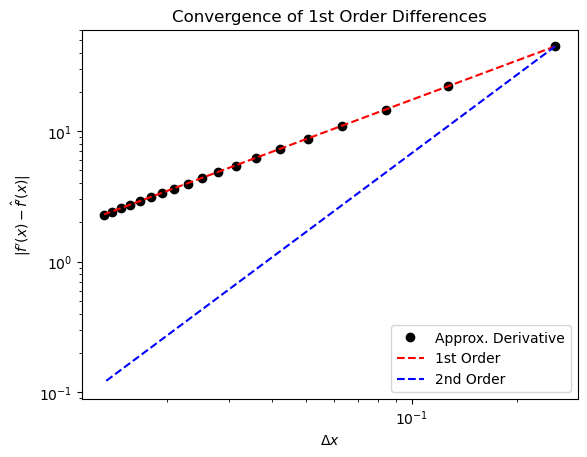

In [ ]:
import numpy                      # Library untuk perhitungan numerik
import matplotlib.pyplot as plt   # Library untuk membuat grafik

# Mendefinisikan fungsi
f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3
# f(x) = sin(x) + x² + 3x³

# Turunan analitik dari fungsi di atas
f_prime = lambda x: numpy.cos(x) + 2.0 * x + 9.0 * x**2
# f'(x) = cos(x) + 2x + 9x²

# Menyimpan nilai Δx dan error
delta_x = []
error = []

# Mengubah jumlah titik grid dari 50 sampai 950
for N in range(50, 1000, 50):

    # Membuat grid dari -2π sampai 2π
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)

    # Menghitung jarak antar titik grid
    delta_x.append(x_hat[1] - x_hat[0])

    # Menghitung turunan numerik dengan Forward Difference
    f_prime_hat = numpy.empty(x_hat.shape)

    f_prime_hat[:-1] = (f(x_hat[1:]) - f(x_hat[:-1])) / (delta_x[-1])
    # Rumus Forward Difference
    # f'(x) ≈ (f(x+Δx) - f(x)) / Δx

    # Menggunakan Backward Difference untuk titik terakhir
    f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x[-1]

    # Menghitung error maksimum antara turunan analitik dan numerik
    error.append(
        numpy.linalg.norm(
            numpy.abs(f_prime(x_hat + delta_x[-1]) - f_prime_hat),
            ord=numpy.inf
        )
    )
    # norm infinity = error maksimum

# Mengubah list menjadi array numpy
error = numpy.array(error)
delta_x = numpy.array(delta_x)

# Membuat grafik
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot error terhadap Δx
axes.loglog(delta_x, error, 'ko', label="Approx. Derivative")
# loglog berarti skala logaritmik pada sumbu x dan y

# Fungsi untuk membuat garis referensi orde error
order_C = lambda delta_x, error, order: numpy.exp(
    numpy.log(error) - order * numpy.log(delta_x)
)

# Garis referensi orde 1
axes.loglog(
    delta_x,
    order_C(delta_x[0], error[0], 1.0) * delta_x**1.0,
    'r--',
    label="1st Order"
)

# Garis referensi orde 2
axes.loglog(
    delta_x,
    order_C(delta_x[0], error[0], 2.0) * delta_x**2.0,
    'b--',
    label="2nd Order"
)

# Menampilkan legenda
axes.legend(loc=4)

# Judul grafik
axes.set_title("Convergence of 1st Order Differences")

# Label sumbu x
axes.set_xlabel("$\Delta x$")

# Label sumbu y
axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$")

# Menampilkan grafik
plt.show()

<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:93: SyntaxWarning: invalid escape sequence '\h'
<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:93: SyntaxWarning: invalid escape sequence '\h'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9908\1095227519.py:92: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta x$")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9908\1095227519.py:93: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$")


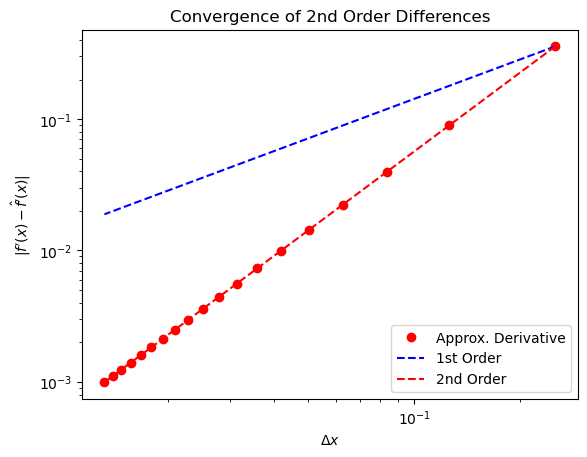

In [ ]:
import numpy                      # Library untuk perhitungan numerik
import matplotlib.pyplot as plt   # Library untuk membuat grafik

# Mendefinisikan fungsi
f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3
# f(x) = sin(x) + x² + 3x³

# Turunan analitik dari fungsi tersebut
f_prime = lambda x: numpy.cos(x) + 2.0 * x + 9.0 * x**2
# f'(x) = cos(x) + 2x + 9x²

# Menyimpan nilai Δx dan error
delta_x = []
error = []

# Menghitung error untuk berbagai jumlah grid
for N in range(50, 1000, 50):

    # Membuat grid dari -2π sampai 2π
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N + 1)

    # Menghitung jarak antar titik grid
    delta_x.append(x_hat[1] - x_hat[0])

    # Menghitung turunan numerik
    f_prime_hat = numpy.empty(x_hat.shape)

    # Menggunakan Central Difference (orde 2) untuk titik tengah
    f_prime_hat[1:-1] = (f(x_hat[2:]) - f(x_hat[:-2])) / (2 * delta_x[-1])
    # Rumus:
    # f'(x) ≈ (f(x+Δx) - f(x-Δx)) / (2Δx)

    # Untuk titik batas (edge domain)

    # Rumus orde 1 (tidak digunakan di sini)
    # f_prime_hat[0] = (f(x_hat[1]) - f(x_hat[0])) / delta_x[-1]
    # f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x[-1]

    # Menggunakan skema orde 2 untuk titik pertama
    f_prime_hat[0] = (-3.0 * f(x_hat[0]) + 4.0 * f(x_hat[1]) - f(x_hat[2])) / (2.0 * delta_x[-1])

    # Menggunakan skema orde 2 untuk titik terakhir
    f_prime_hat[-1] = (3.0 * f(x_hat[-1]) - 4.0 * f(x_hat[-2]) + f(x_hat[-3])) / (2.0 * delta_x[-1])

    # Menghitung error maksimum
    error.append(
        numpy.linalg.norm(
            numpy.abs(f_prime(x_hat) - f_prime_hat),
            ord=numpy.inf
        )
    )

# Mengubah list menjadi array
error = numpy.array(error)
delta_x = numpy.array(delta_x)

# Membuat grafik
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot error
axes.loglog(delta_x, error, "ro", label="Approx. Derivative")

# Fungsi untuk membuat garis referensi orde error
order_C = lambda delta_x, error, order: numpy.exp(
    numpy.log(error) - order * numpy.log(delta_x)
)

# Garis referensi orde 1
axes.loglog(
    delta_x,
    order_C(delta_x[0], error[0], 1.0) * delta_x**1.0,
    'b--',
    label="1st Order"
)

# Garis referensi orde 2
axes.loglog(
    delta_x,
    order_C(delta_x[0], error[0], 2.0) * delta_x**2.0,
    'r--',
    label="2nd Order"
)

# Menampilkan legenda
axes.legend(loc=4)

# Judul grafik
axes.set_title("Convergence of 2nd Order Differences")

# Label sumbu
axes.set_xlabel("$\Delta x$")
axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$")

# Menampilkan grafik
plt.show()

<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:93: SyntaxWarning: invalid escape sequence '\h'
<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:93: SyntaxWarning: invalid escape sequence '\h'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9908\1095227519.py:92: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta x$")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9908\1095227519.py:93: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$")


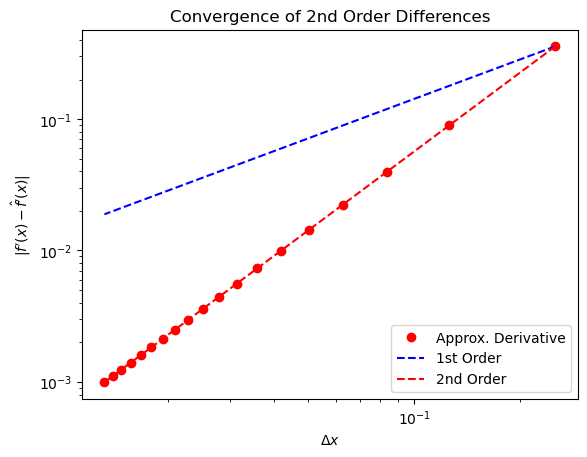

In [ ]:
import numpy                      # Library untuk perhitungan numerik
import matplotlib.pyplot as plt   # Library untuk membuat grafik

# Mendefinisikan fungsi
f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3
# f(x) = sin(x) + x² + 3x³

# Turunan analitik dari fungsi tersebut
f_prime = lambda x: numpy.cos(x) + 2.0 * x + 9.0 * x**2
# f'(x) = cos(x) + 2x + 9x²

# Menyimpan nilai Δx dan error
delta_x = []
error = []

# Menghitung error untuk berbagai jumlah grid
for N in range(50, 1000, 50):

    # Membuat grid dari -2π sampai 2π
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N + 1)

    # Menghitung jarak antar titik grid
    delta_x.append(x_hat[1] - x_hat[0])

    # Menghitung turunan numerik
    f_prime_hat = numpy.empty(x_hat.shape)

    # Menggunakan Central Difference (orde 2) untuk titik tengah
    f_prime_hat[1:-1] = (f(x_hat[2:]) - f(x_hat[:-2])) / (2 * delta_x[-1])
    # Rumus:
    # f'(x) ≈ (f(x+Δx) - f(x-Δx)) / (2Δx)

    # Untuk titik batas (edge domain)

    # Rumus orde 1 (tidak digunakan di sini)
    # f_prime_hat[0] = (f(x_hat[1]) - f(x_hat[0])) / delta_x[-1]
    # f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x[-1]

    # Menggunakan skema orde 2 untuk titik pertama
    f_prime_hat[0] = (-3.0 * f(x_hat[0]) + 4.0 * f(x_hat[1]) - f(x_hat[2])) / (2.0 * delta_x[-1])

    # Menggunakan skema orde 2 untuk titik terakhir
    f_prime_hat[-1] = (3.0 * f(x_hat[-1]) - 4.0 * f(x_hat[-2]) + f(x_hat[-3])) / (2.0 * delta_x[-1])

    # Menghitung error maksimum
    error.append(
        numpy.linalg.norm(
            numpy.abs(f_prime(x_hat) - f_prime_hat),
            ord=numpy.inf
        )
    )

# Mengubah list menjadi array
error = numpy.array(error)
delta_x = numpy.array(delta_x)

# Membuat grafik
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot error
axes.loglog(delta_x, error, "ro", label="Approx. Derivative")

# Fungsi untuk membuat garis referensi orde error
order_C = lambda delta_x, error, order: numpy.exp(
    numpy.log(error) - order * numpy.log(delta_x)
)

# Garis referensi orde 1
axes.loglog(
    delta_x,
    order_C(delta_x[0], error[0], 1.0) * delta_x**1.0,
    'b--',
    label="1st Order"
)

# Garis referensi orde 2
axes.loglog(
    delta_x,
    order_C(delta_x[0], error[0], 2.0) * delta_x**2.0,
    'r--',
    label="2nd Order"
)

# Menampilkan legenda
axes.legend(loc=4)

# Judul grafik
axes.set_title("Convergence of 2nd Order Differences")

# Label sumbu
axes.set_xlabel("$\Delta x$")
axes.set_ylabel("$|f'(x) - \hat{f}'(x)|$")

# Menampilkan grafik
plt.show()